In [5]:
import pandas as pd

In [25]:
kpi = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\kpi_summary.csv", header=None,
    names=["total_orders", "total_users", "total_products", "reorder_rate_pct", "avg_basket_size"]
)

In [29]:
kpi.columns = [
    "total_orders",
    "total_users",
    "total_products",
    "reorder_rate_pct",
    "avg_basket_size"
]

kpi.head()

,total_orders,total_users,total_products,reorder_rate_pct,avg_basket_size
0,3214874,206209,49428,58.969747,10.088883


In [33]:
product = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\product_analysis.csv",
    header=None,
    names=["product_id", "product_name", "aisle", "department", "total_orders", "total_reorders", "reorder_rate_pct"]
)
product.head()

,product_id,product_name,aisle,department,total_orders,total_reorders,reorder_rate_pct
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks,1852,1136,61.339093
1,2,All-Seasons Salt,spices seasonings,pantry,90,12,13.333333
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages,277,203,73.285199
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,frozen,329,147,44.680851
4,5,Green Chile Anytime Sauce,marinades meat preparation,pantry,15,9,60.000000


In [35]:
timing = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\order_timing.csv",
    header=None,
    names=["order_dow", "order_hour_of_day", "total_orders"]
)
timing.head()

,order_dow,order_hour_of_day,total_orders
0,0,0,3692
1,0,23,6393
2,2,11,36186
3,3,4,666
4,5,15,35218


In [37]:
print("Total Orders:", int(kpi["total_orders"].iloc[0]))
print("Total Users:", int(kpi["total_users"].iloc[0]))
print("Total Products:", int(kpi["total_products"].iloc[0]))
print("Reorder Rate:", round(kpi["reorder_rate_pct"].iloc[0], 2), "%")
print("Average Basket Size:", round(kpi["avg_basket_size"].iloc[0], 2))

Total Orders: 3214874
Total Users: 206209
Total Products: 49428
Reorder Rate: 58.97 %
Average Basket Size: 10.09


In [39]:
import matplotlib.pyplot as plt

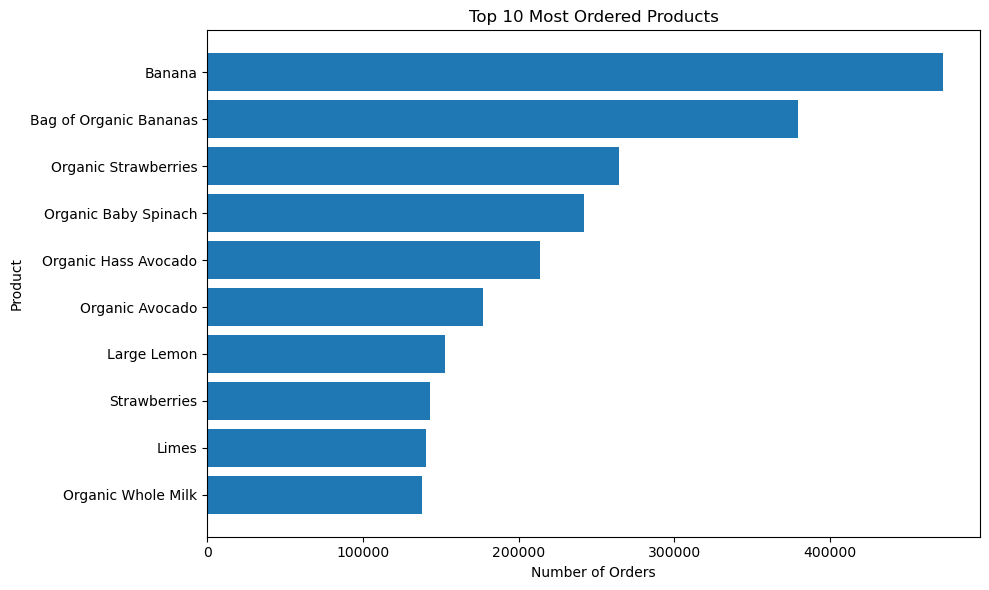

In [41]:


top_products = (
    product
    .sort_values("total_orders", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["product_name"],
    top_products["total_orders"]
)

plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.title("Top 10 Most Ordered Products")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

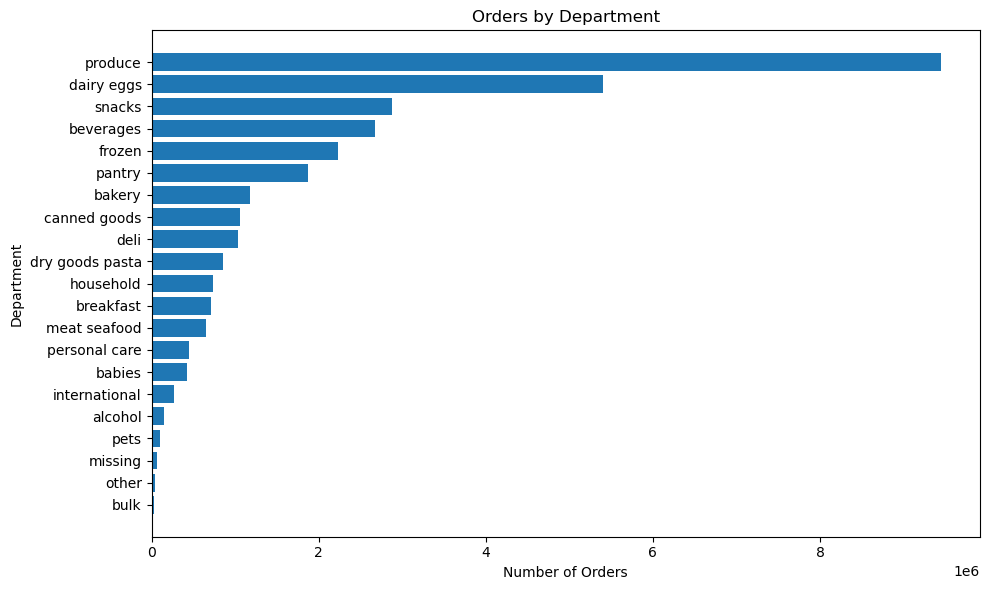

In [43]:
department_orders = (
    product
    .groupby("department")["total_orders"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    department_orders.index,
    department_orders.values
)

plt.xlabel("Number of Orders")
plt.ylabel("Department")
plt.title("Orders by Department")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [48]:
import matplotlib.pyplot as plt


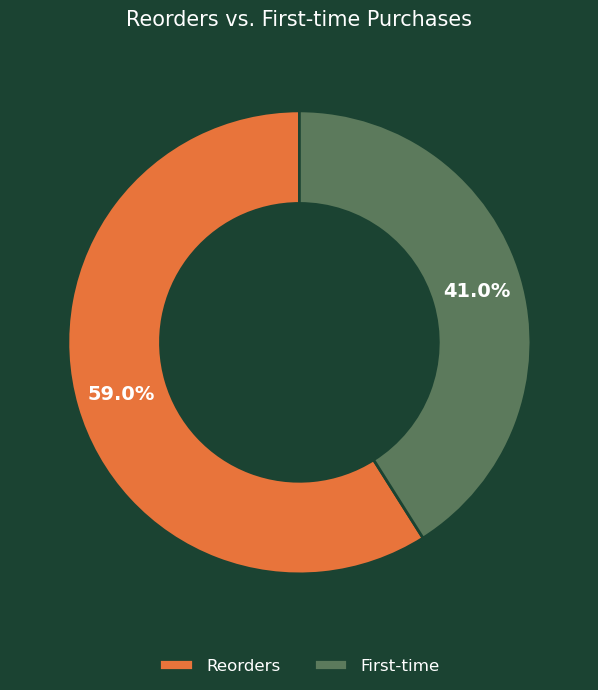

In [50]:

# Pull the reorder rate straight from your existing kpi dataframe
reorder_pct = kpi['reorder_rate_pct'][0]
first_time_pct = 100 - reorder_pct

labels = ['Reorders', 'First-time']
values = [reorder_pct, first_time_pct]

# Colors matching your Power BI screenshot: orange for Reorders, sage/green for First-time
colors = ['#E8743B', '#5C7A5C']

# Dark green background like your screenshot
bg_color = '#1B4332'

fig, ax = plt.subplots(figsize=(7, 7), facecolor=bg_color)
ax.set_facecolor(bg_color)

wedges, texts, autotexts = ax.pie(
    values,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor=bg_color, linewidth=2),
    pctdistance=0.8,
    textprops={'fontsize': 14, 'color': 'white', 'fontweight': 'bold'}
)

plt.title("Reorders vs. First-time Purchases", fontsize=15, color='white', pad=20)

# Legend styled to match — white text, no border, placed below
legend = plt.legend(
    wedges, labels,
    loc='upper center', bbox_to_anchor=(0.5, -0.02),
    ncol=2, frameon=False, fontsize=12
)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig('reorder_split_donut.png', dpi=150, facecolor=bg_color, bbox_inches='tight')
plt.show()

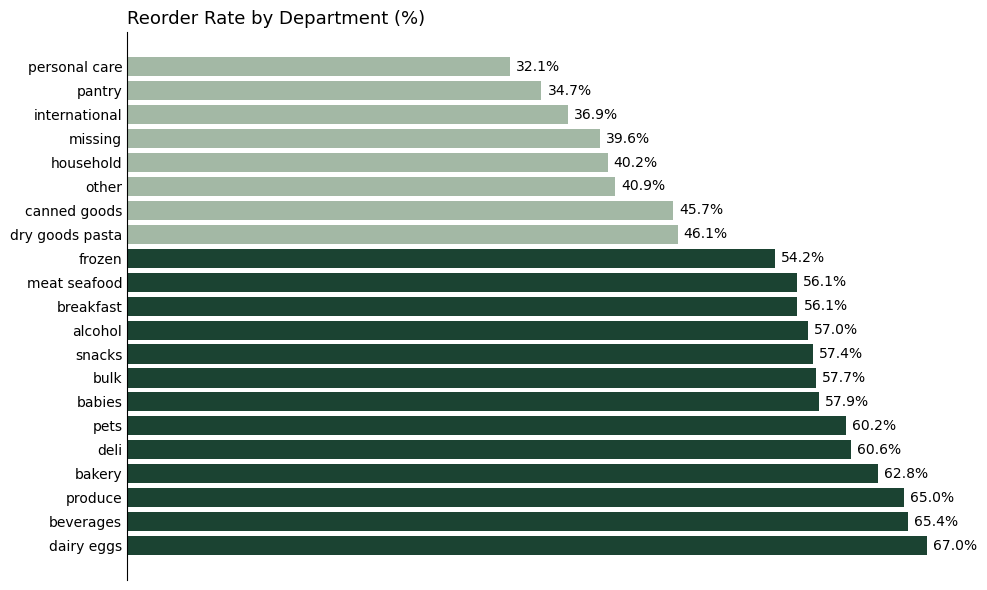

In [52]:


# Load the correct data
dept_reorder = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\reorder_rate_by_department.csv")

highlight_color = '#1B4332'   # dark forest green — for top-performing bars
muted_color = '#A3B8A5'       # sage green — for lower-performing bars

# Set a threshold to decide which bars get which color
# (e.g., anything below 50% reorder rate gets the muted color)
colors = [highlight_color if val >= 50 else muted_color 
          for val in dept_reorder['reorder_rate_pct']]

plt.figure(figsize=(10, 6))
bars = plt.barh(
    dept_reorder['department'],
    dept_reorder['reorder_rate_pct'],
    color=colors
)

# Add value labels at the end of each bar, like your slide
for bar, val in zip(bars, dept_reorder['reorder_rate_pct']):
    plt.text(
        bar.get_width() + 0.5, 
        bar.get_y() + bar.get_height()/2, 
        f'{val:.1f}%', 
        va='center', fontsize=10
    )

plt.xlabel("")
plt.title("Reorder Rate by Department (%)", fontsize=13, loc='left')

# Clean up the look — remove chart borders/gridlines like your slide
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.xticks([])  # hides x-axis numbers since value labels are already on bars

plt.tight_layout()
plt.savefig('department_reorder_rate_styled.png', dpi=150, bbox_inches='tight')
plt.show()

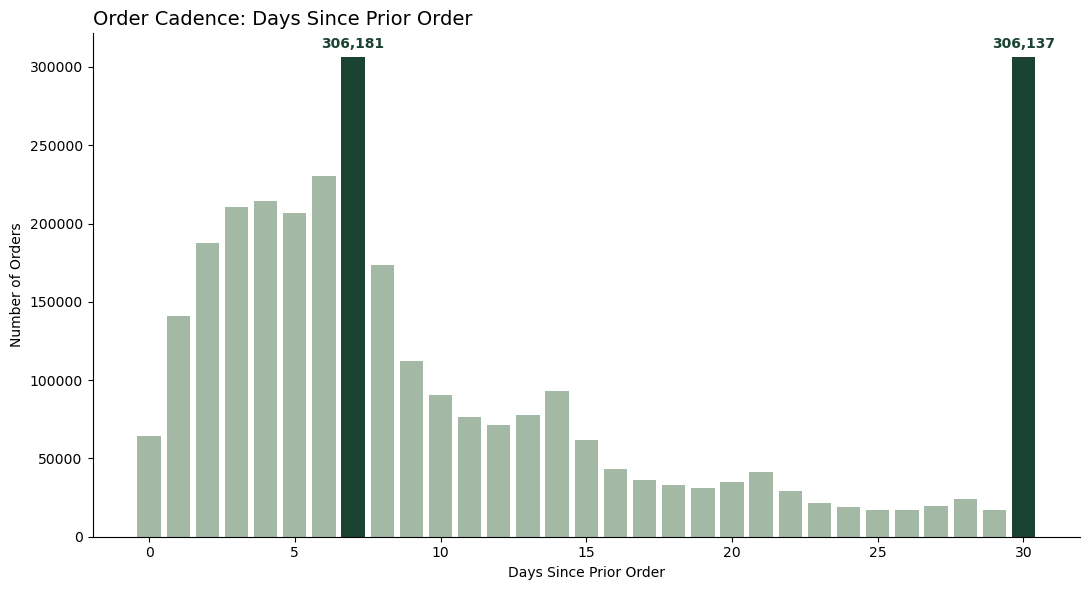

In [54]:


# Load data
df = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\days_since_prior_order.csv")


# Theme colors, matching your other slides
bar_color = '#A3B8A5'        # sage green — default bars
highlight_color = '#1B4332'  # dark green — highlighted peak bars

# Color each bar: highlight day 7 and day 30, sage for everything else
colors = [highlight_color if day in [7, 30] else bar_color 
          for day in df['days_since_prior_order']]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    df['days_since_prior_order'],
    df['order_count'],
    color=colors
)

# Label the day 7 and day 30 bars specifically
for day in [7, 30]:
    if day in df['days_since_prior_order'].values:
        value = df.loc[df['days_since_prior_order'] == day, 'order_count'].values[0]
        ax.text(
            day, value + max(df['order_count'])*0.02,
            f'{value:,.0f}',
            ha='center', fontsize=10, fontweight='bold', color=highlight_color
        )

ax.set_xlabel("Days Since Prior Order")
ax.set_ylabel("Number of Orders")
ax.set_title("Order Cadence: Days Since Prior Order", fontsize=14, loc='left')

# Clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('days_since_prior_order_bar.png', dpi=150, bbox_inches='tight')
plt.show()

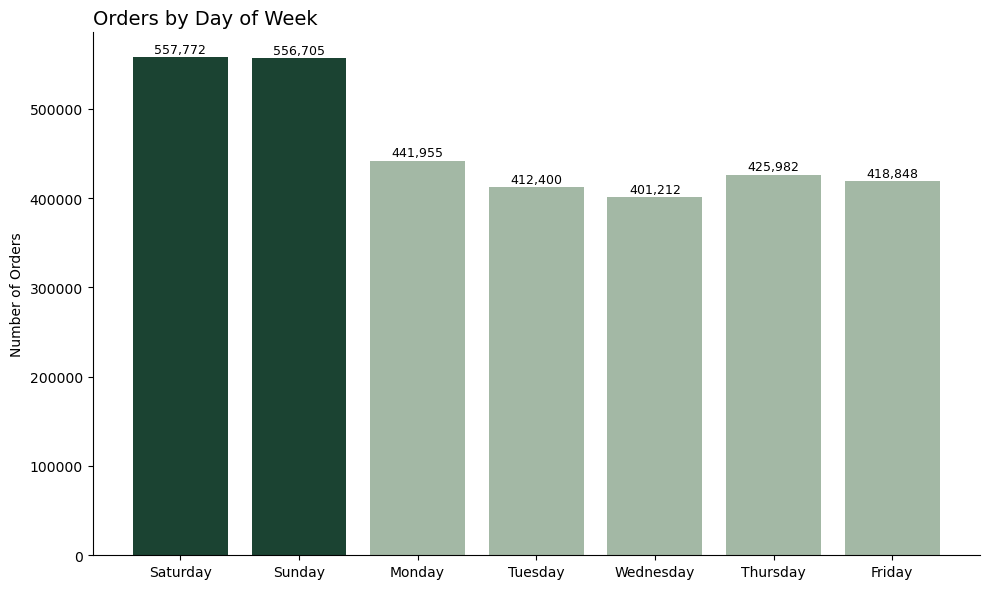

In [58]:

df = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\orders_by_dow.csv")

# Map order_dow numbers to actual day names (0 = Saturday, 1 = Sunday, per the dataset)
day_names = {0: 'Saturday', 1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 
             4: 'Wednesday', 5: 'Thursday', 6: 'Friday'}
df['day_name'] = df['order_dow'].map(day_names)

# Reorder so the week reads Sat -> Fri, matching the dataset's own numbering
df = df.sort_values('order_dow')

bar_color = '#A3B8A5'
highlight_color = '#1B4332'
colors = [highlight_color if d in [0, 1] else bar_color for d in df['order_dow']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df['day_name'], df['total_orders'], color=colors)

for bar, val in zip(bars, df['total_orders']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5000, f'{val:,.0f}', 
            ha='center', fontsize=9)

ax.set_xlabel("")
ax.set_ylabel("Number of Orders")
ax.set_title("Orders by Day of Week", fontsize=14, loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('orders_by_dow.png', dpi=150, bbox_inches='tight')
plt.show()

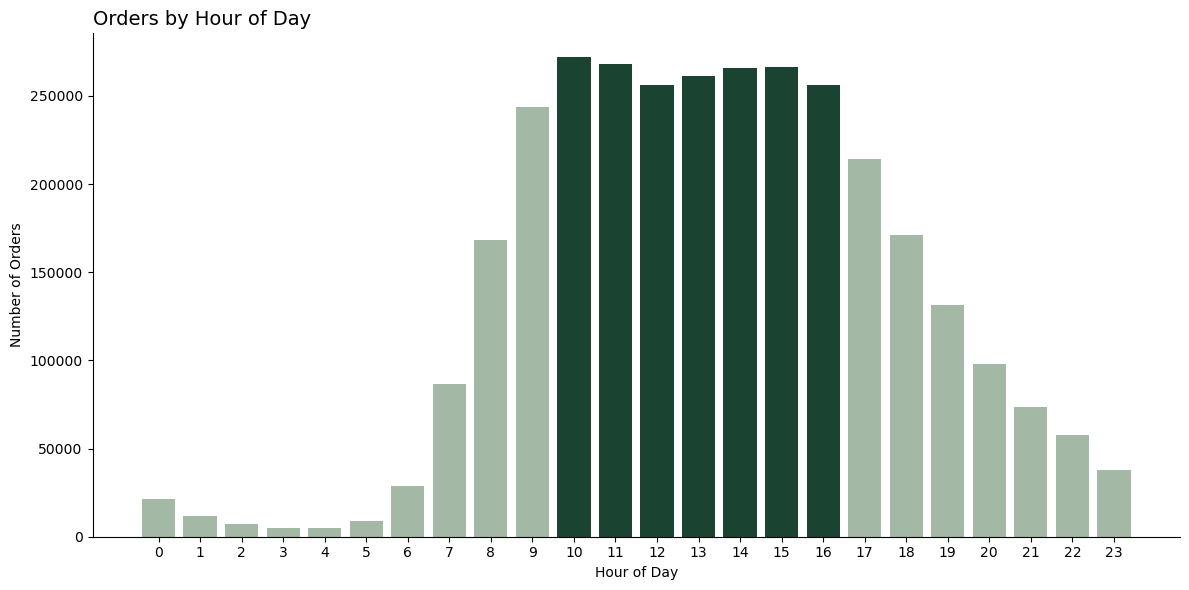

In [64]:


df = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\orders_by_hour.csv")
df = df.sort_values('order_hour_of_day')

bar_color = '#A3B8A5'
highlight_color = '#1B4332'

# Highlight the 10am-4pm window (hours 10-16)
colors = [highlight_color if 10 <= h <= 16 else bar_color 
          for h in df['order_hour_of_day']]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df['order_hour_of_day'], df['total_orders'], color=colors)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Orders")
ax.set_title("Orders by Hour of Day", fontsize=14, loc='left')
ax.set_xticks(range(0, 24))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('orders_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

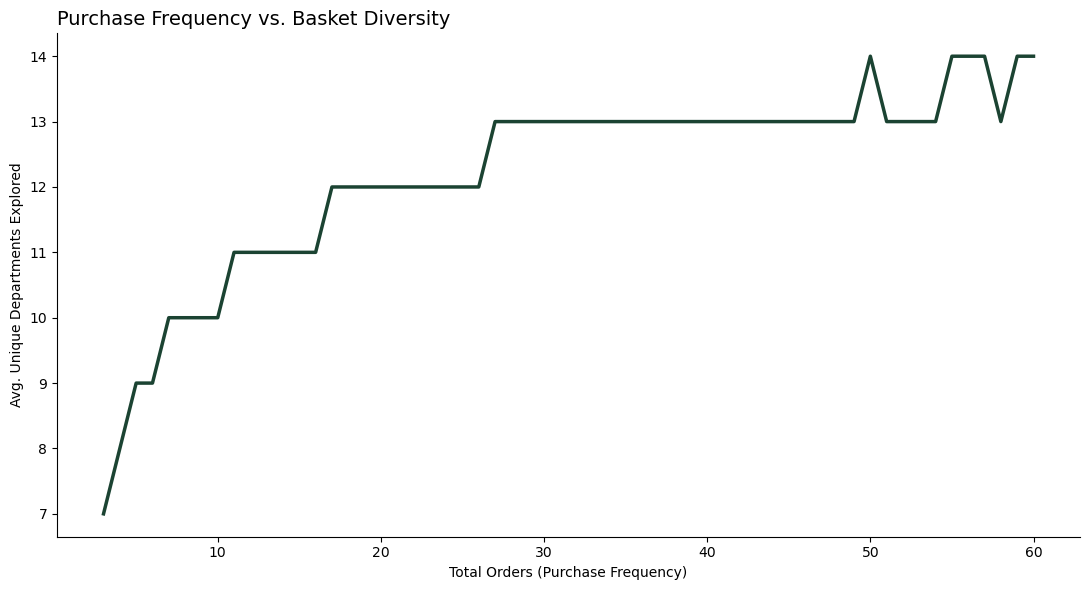

In [9]:
df = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\frequency_vs_diversity.csv")

# Restrict to order counts with a reliable customer sample size
# (using the same reasoning as your product-threshold decision)
df_clean = df[df['total_orders'] <= 60]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df_clean['total_orders'], df_clean['avg_unique_departments'], 
        color='#1B4332', linewidth=2.5)

ax.set_xlabel("Total Orders (Purchase Frequency)")
ax.set_ylabel("Avg. Unique Departments Explored")
ax.set_title("Purchase Frequency vs. Basket Diversity", fontsize=14, loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('frequency_vs_diversity_clean.png', dpi=150, bbox_inches='tight')
plt.show()

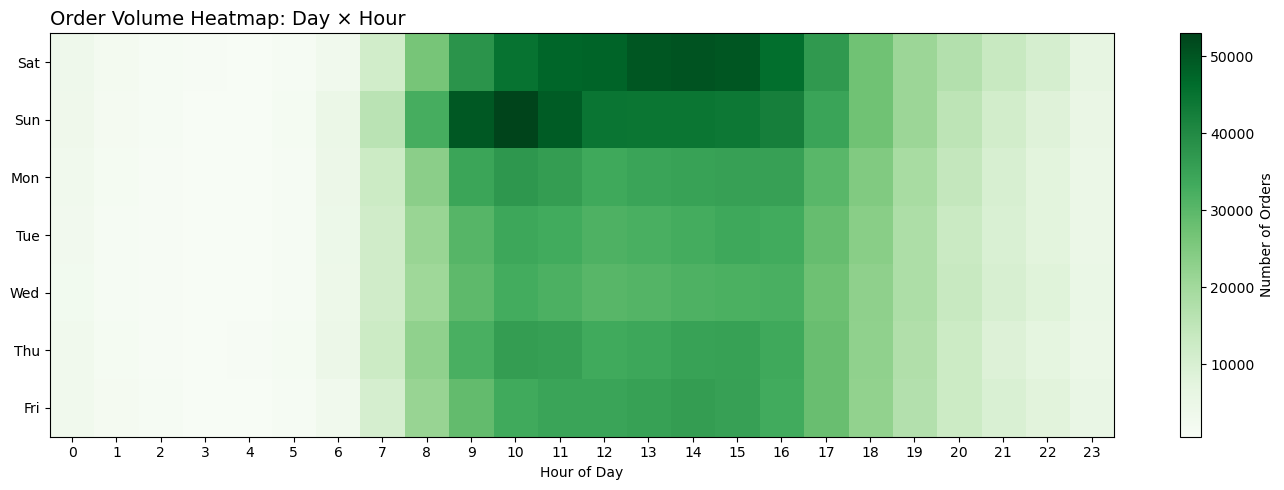

In [60]:



import numpy as np

df = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\hour_dow_heatmap.csv")

day_names = {0: 'Sat', 1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri'}
df['day_name'] = df['order_dow'].map(day_names)

# Pivot into a grid: rows = day, columns = hour
pivot = df.pivot(index='day_name', columns='order_hour_of_day', values='total_orders')
pivot = pivot.reindex(['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri'])  # keep dataset's week order

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, cmap='Greens', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Hour of Day")
ax.set_title("Order Volume Heatmap: Day × Hour", fontsize=14, loc='left')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of Orders")

plt.tight_layout()
plt.savefig('hour_dow_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\sumit\AppData\Local\Temp\ipykernel_10552\1864666869.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['frequency_segment'], rotation=15, ha='right', fontsize=9)
C:\Users\sumit\AppData\Local\Temp\ipykernel_10552\1864666869.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['frequency_segment'], rotation=15, ha='right', fontsize=9)
C:\Users\sumit\AppData\Local\Temp\ipykernel_10552\1864666869.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['frequency_segment'], rotation=15, ha='right', fontsize=9)


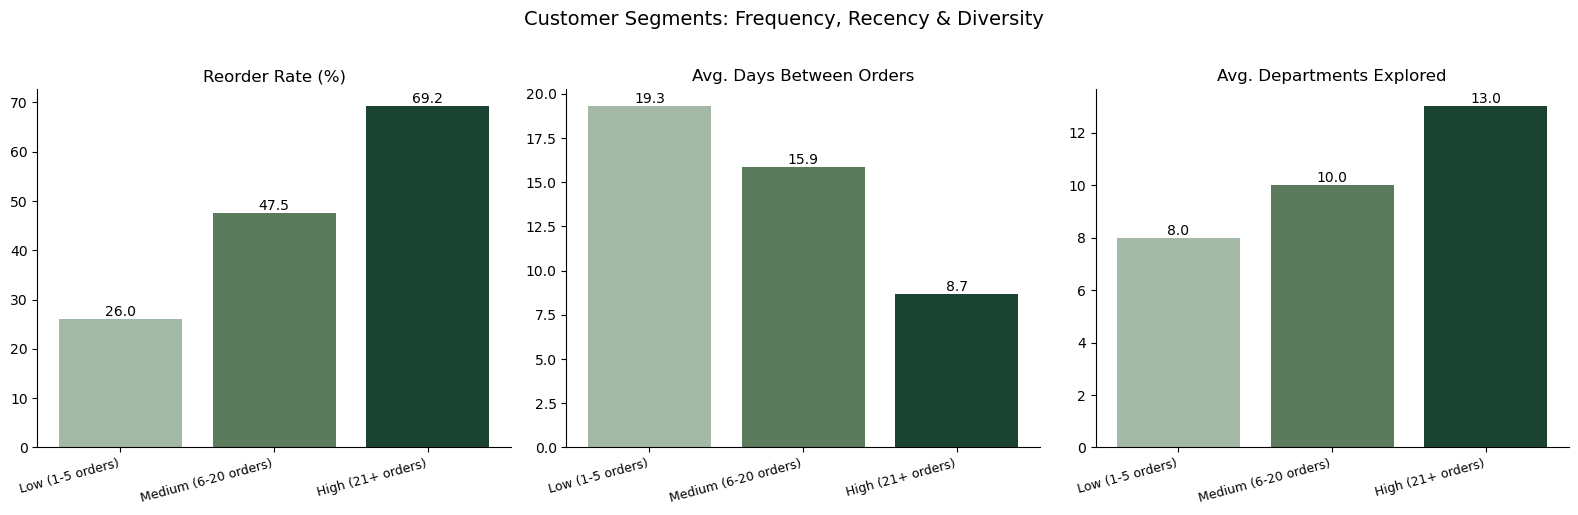

In [61]:




df = pd.read_csv(r"C:\Users\sumit\OneDrive\Documents\Instacart\customer_segments.csv")

# Ensure segment order is Low -> Medium -> High
segment_order = ['Low (1-5 orders)', 'Medium (6-20 orders)', 'High (21+ orders)']
df['frequency_segment'] = pd.Categorical(df['frequency_segment'], categories=segment_order, ordered=True)
df = df.sort_values('frequency_segment')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [
    ('reorder_rate_pct', 'Reorder Rate (%)'),
    ('avg_recency_days', 'Avg. Days Between Orders'),
    ('avg_dept_diversity', 'Avg. Departments Explored')
]

colors = ['#A3B8A5', '#5C7A5C', '#1B4332']  # Low, Medium, High

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(df['frequency_segment'], df[col], color=colors)
    for bar, val in zip(bars, df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}', 
                ha='center', va='bottom', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels(df['frequency_segment'], rotation=15, ha='right', fontsize=9)

plt.suptitle("Customer Segments: Frequency, Recency & Diversity", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()